<font size=10>**Prompt Engineering**</font>

<font size=6>**AI-Assisted Differential Diagnosis**</font>

# **Business Problem - Enhancing Triage with Prompt Engineering**



In the healthcare domain, timely and accurate diagnosis of medical conditions is crucial for effective treatment and improved patient outcomes. However, the differential diagnosis process is often complex and time-consuming, especially when multiple symptoms overlap across different medical conditions.

Medical practitioners face the challenge of manually analyzing patient symptoms, which can lead to delays, inefficiencies, and potential misdiagnoses. Traditional methods of diagnosis rely heavily on the experience of the practitioner, making the process prone to variability and subjectivity.

To address these challenges, the healthcare sector is increasingly exploring AI-based solutions to improve diagnostic processes. Leveraging Generative AI models can significantly enhance the accuracy, speed, and consistency of differential diagnosis by understanding the relationship between patient symptoms and possible medical conditions.

The objective of this case study is to build an AI-powered differential diagnosis system that serves as a decision support tool for healthcare professionals, ultimately improving diagnostic accuracy and patient care.

# **<font color='blue'>Environment Setup & Installation</font>**

This section involves setting up the environment and installing the necessary libraries required for running the AI model.

This command checks if the Colab notebook or local environment has access to an NVIDIA GPU. The NVIDIA System Management Interface (`nvidia-smi`) displays details about the available GPUs such as memory, usage, and driver versions. A GPU helps in faster inference for models like LLaMA.

In [1]:
# GPU availability check
!nvidia-smi

Sun Jun 29 18:56:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.94                 Driver Version: 560.94         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   47C    P8             18W /  200W |    4206MiB /  12282MiB |     45%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

- This command installs the `llama-cpp-python` library, which provides bindings to run LLaMA models on both CPU and GPU.
- The parameter `-DLLAMA_CUBLAS=on` enables CUDA BLAS support, which allows the model to perform matrix operations on the GPU.

In [2]:
# Installation for GPU llama-cpp-python
#!pip install llama-cpp-python==0.2.28 --force-reinstall --upgrade --no-cache-dir --verbose -q

We will be installing the following Libraries

In [3]:
# Install required libraries
#!pip install --upgrade numpy==1.26.4
#scipy huggingface_hub==0.29.1 datasets evaluate==0.4.3 matplotlib seaborn==0.12.2 pandas

- **numpy, scipy:** For numerical computations.

- **huggingface_hub:** To interact with the Hugging Face model hub.

- **datasets:** For loading benchmark datasets.

- **evaluate:** For performance evaluation.

- **matplotlib, seaborn:** For data visualization.



In [4]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import seaborn as sn

c:\Users\Pheon\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Loading the Dataset. The `df.head()` function displays the first five rows of the dataset to give a quick preview of its structure.

In [5]:
dataset_path = "differential_diagnosis_dataset.csv"
diagnosis_df = pd.read_csv(dataset_path)

In [6]:
# Display dataset sample
diagnosis_df.head()

,Patient_ID,Age,Gender,Symptom,Diagnosis_Category,Possible_Diagnosis
0,e5196724-d926-4fd7-bc20-e76a16b3d8a6,10,Female,wheezing,Respiratory Issues,asthma
1,1701efa5-1d30-4492-89c3-5f5f3174bf2e,24,Female,chest pain,Respiratory Issues,asthma
2,d307040a-3519-4c22-b676-ad10f3da80b1,66,Female,shortness of breath,Respiratory Issues,pneumonia
3,4ca668f9-077f-446e-aac5-8fb91d79b0b6,64,Female,rapid breathing,Respiratory Issues,pneumonia
4,8365de28-a73a-425d-8dce-6d6ada05d9c1,60,Female,cough,Respiratory Issues,pneumonia


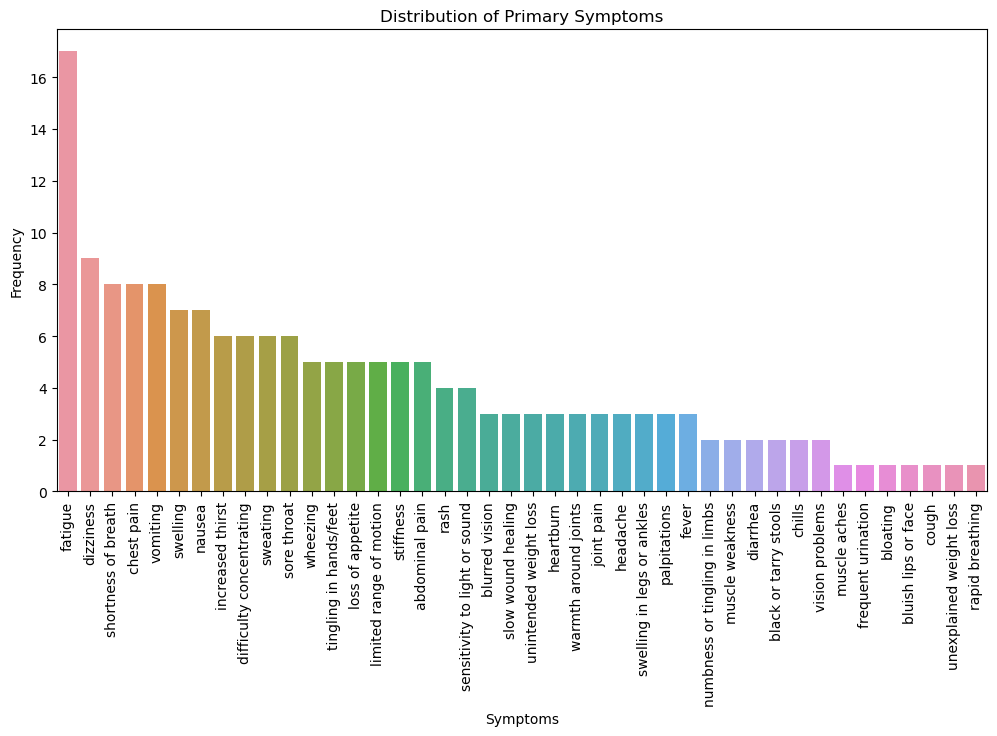

In [7]:
# Visualizing Symptom Distribution
plt.figure(figsize=(12, 6))
sn.countplot(data=diagnosis_df, x='Symptom', order=diagnosis_df['Symptom'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Distribution of Primary Symptoms')
plt.xlabel('Symptoms')
plt.ylabel('Frequency')
plt.show()

# **<font color='blue'>Model Loading and Configuration</font>**



This section demonstrates how to load the **Meta-Llama-3-8B-Instruct** model using the `llama-cpp-python` library.

In [8]:
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

**Model Download:** The model is downloaded from Hugging Face's model hub using the `hf_hub_download()` method.

- The `model_name_or_path` specifies the model repository.

- The `filename` parameter defines which quantized model version to download.

- **Meta-Llama-3-8B-Instruct** → Meta's **LLaMA-3 model** (8 Billion parameters version).
- **Instruct** → It is an **instruction-tuned mode**l optimized for conversational or prompt-based tasks like Q&A or diagnosis.
- **Q8_0** → This denotes **Quantization Level (Q8)**

  Quantization is a compression technique to reduce model size and improve inference speed. Quantization reduces the size of the model by representing weights with fewer bits (e.g., 4-bit, 8-bit) instead of the original 16-bit or 32-bit floating-point numbers.

  *Q8_0 means 8-bit quantization, which provides better model accuracy compared to lower quantization levels like Q4_0 or Q5_0, but requires more memory and computational resources.*

In [9]:
model_name_or_path = "QuantFactory/Meta-Llama-3-8B-Instruct-GGUF"
model_basename = "Meta-Llama-3-8B-Instruct.Q8_0.gguf"

# Download model from Hugging Face
model_path = hf_hub_download(
    repo_id=model_name_or_path,
    filename=model_basename
)

🔥 What Will Changing the Model Affect?

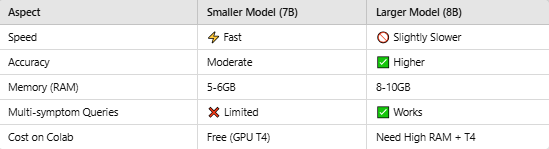

**Model Initialization:**

The `Llama()` class is used to initialize the model with the following parameters:

- `model_path`: Path to the downloaded model.

- `n_threads`: Number of CPU threads to use.

- `n_batch`: The batch size for processing tokens.

- `n_gpu_layers`: Number of layers to offload to the GPU for faster inference.

- `n_ctx`: The context window size, which defines how many tokens the model can consider at once.

In [10]:
llm = Llama(
    model_path=model_path,
    n_threads= 4, # CPU cores
    n_batch=256, # Should be between 1 and n_ctx, consider the amount of VRAM in your GPU.
    n_gpu_layers=43, # Change this value based on your model and your GPU VRAM pool.
    n_ctx=8192 # Context window
)

AVX = 1 | AVX_VNNI = 0 | AVX2 = 1 | AVX512 = 0 | AVX512_VBMI = 0 | AVX512_VNNI = 0 | FMA = 1 | NEON = 0 | ARM_FMA = 0 | F16C = 1 | FP16_VA = 0 | WASM_SIMD = 0 | BLAS = 0 | SSE3 = 1 | SSSE3 = 0 | VSX = 0 | 


**Model Inference Function:**

The `lcpp_llm()` function acts as an interface to generate model responses.

Parameters:

- `prompt:` The input text for the model.

- `max_tokens:` Maximum number of tokens to generate.

- `temperature:` Controls randomness (lower values yield more deterministic outputs).

- `stop:` List of stop words that halt generation when encountered.

In [11]:
# Function to generate model responses
def lcpp_llm(prompt, max_tokens=256, temperature=0, stop=["USER"]):
    return llm(prompt, max_tokens=max_tokens, temperature=temperature, stop=stop)

This setup ensures that the model is correctly loaded and ready to generate predictions.

# **<font color='blue'>Prompt Engineering</font>**

In this section, we explore different prompting techniques to generate medical diagnoses from the LLaMA model.

**Prompt Engineering** is a critical technique in LLM-based applications to guide the model in generating structured and accurate responses. This section demonstrates three prompting methods: **Few Shot, Chain of Thought (CoT), and Tree of Thought (ToT)**, applied to the differential diagnosis use case.

**Extracting Diagnoses using Regex**

We define a helper function `extract_list()`** that uses regular expressions to extract list-based diagnoses from the model's response.

***It will be used after this section for inference.*

In [12]:
# Function to extract diagnosis lists using regex
import json
import re

def extract_list(text):
    match = re.search(r'\[(.*?)\]', text)
    if match:
        items = match.group(1).split(",")
        return [item.strip() for item in items]
    return []

Give a common `user_query` which can be changed and edited in this format for multiple use case.

*Format:* `"A {age}-year-old {gender}, {symptom/symptoms}."`

In [13]:
user_query = "A 35-year-old male, fever, wheezing, nausea."

## **Zero-Shot Prompting**

In [14]:
def zero_shot_prompting(observations):
    responses = []
    for index, observation in observations.iterrows():
        symptom_prompt = f"""
        SYSTEM: Provide the final list of probable diagnoses in the format provided below, with brackets surrounding all three diagnoses.
        OUTPUT: Most probable diagnosis: [Diagnosis 1, Diagnosis 2, Diagnosis 3]
        USER: What are the possible causes of {observation['Symptom']} in a {observation['Age']}-year-old {observation['Gender']}? 
        """
        response = lcpp_llm(symptom_prompt)
        output_few_shot = response['choices'][0]['text'].strip()
        responses.append(output_few_shot)
    return responses

## **Instruction-Tuned Format**

In [15]:
def instruction_tuned_format(observations):
    responses = []
    for index, observation in observations.iterrows():
        symptom_prompt = f"""
        SYSTEM: You are a medical AI assistant. Given the following symptoms, patient age and gender, provide a differential diagnosis with probability scores. 

        Provide the the final list of probable diagnoses in the format provided below.

        OUTPUT: 
        Probabilities: 
         - Diagnosis 1 : Diagnosis 1 probability
         - Diagnosis 2 : Diagnosis 2 probability
         - Diagnosis 3 : Diagnosis 3 probability
        Most probable diagnosis: [Diagnosis 1, Diagnosis 2, Diagnosis 3]

        USER: 
        The patient is a {observation['Age']}-year-old {observation['Gender']} with symptoms of {observation['Symptom']}
        """
        response = lcpp_llm(symptom_prompt)
        output_few_shot = response['choices'][0]['text'].strip()
        responses.append(output_few_shot)
    return responses


## **Chain of Thought (CoT) Prompting**

Chain of Thought prompting encourages the model to explain its reasoning step-by-step before providing the final diagnosis.

- The model is instructed to break down its reasoning process into three steps:

  1. Analyzing symptoms.

  2. Listing possible conditions.

  3. Providing the final diagnosis.

- This method helps improve model accuracy by guiding its thought process.

In [ ]:
def chain_of_thought(observations):
    responses = []
    for index, observation in observations.iterrows():
        symptom_prompt = f"""
        SYSTEM:
        You are a medical expert performing differential diagnosis through step-by-step reasoning.
        1. Analyze the symptoms and list underlying possible conditions.
        2. Explain each possibility step-by-step.
        3. Provide the final list of probable diagnoses.

        Provide the final output in the format provided below.
        OUTPUT:
        Explanation of reasoning:
        "
        - Fatigue is a common symptom in many conditions.
        - For a 50-year-old male, fatigue can indicate cardiovascular or metabolic issues.
        - Common diagnoses for fatigue:
            - Anemia
            - Diabetes
            - Thyroid disorder
            - Heart disease "

        Most probable diagnosis: [Diagnosis 1, Diagnosis 2, Diagnosis 3]

        USER: 
        A {observation['Age']}-year-old {observation['Gender']} with {observation['Symptom']}
        """
        response = lcpp_llm(symptom_prompt)
        output_few_shot = response['choices'][0]['text'].strip()
        responses.append(output_few_shot)
    return responses

# **<font color='blue'>Inference and Output Generation</font>**

In this section, we will generate and organize the model's output for each prompting technique into a structured table format. This helps in comparing the diagnoses generated by **Few Shot, Chain of Thought (CoT), and Tree of Thought (ToT)** prompting methods.

1. **Extract Diagnoses Using Regex:**

  - The `extract_list()` function uses regular expressions to extract the list of diagnoses enclosed in square brackets (`[]`) from the model's response text.

  - This ensures that the diagnoses are captured in a structured format for further analysis.

2. **Creating the Diagnoses Table:**

  * The first DataFrame stores the prompting techniques and their corresponding list of diagnoses.

  * This helps visualize how different prompting strategies yield different outcomes.


In [17]:
random_observations = diagnosis_df.sample(n=5)
random_observations.head(5)

,Patient_ID,Age,Gender,Symptom,Diagnosis_Category,Possible_Diagnosis
133,55c84c73-752d-4a92-8fb0-671a8a4dc99c,62,Female,fatigue,Endocrine/Metabolic Conditions,diabetes mellitus
87,a5991127-5072-40d8-a56f-c15e8d57b226,21,Female,dizziness,Neurological Conditions,migraine
60,0c142286-e290-41bc-81ed-4419d9c3d529,83,Female,sweating,Cardiovascular Problems,myocardial infarction
170,55fe91cb-56ce-4c56-a149-d4ff0cb20246,74,Male,joint pain,Musculoskeletal Disorders,gout
120,773991ce-b91f-4e8c-b127-82d29d7279c7,47,Male,vomiting,Gastrointestinal Issues,irritable bowel syndrome


In [18]:
print("Performing Zero Shot Prompting")
zero_shot_diag = zero_shot_prompting(random_observations)
print("Performing Instruction Tuned Prompting")
instruction_diag = instruction_tuned_format(random_observations)
print("Performing Chain of Thought Prompting")
chain_of_thought_diag = chain_of_thought(random_observations)

Performing Zero Shot Prompting


Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


Performing Instruction Tuned Prompting


Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


Performing Chain of Thought Prompting


Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


In [19]:
for line in zero_shot_diag:
    print(line)

The most probable diagnosis for this patient is: [Chronic Fatigue Syndrome, Hypothyroidism, Anemia]. 

Explanation:
Fatigue can be caused by various factors, including chronic medical conditions, medications, and lifestyle. In a 62-year-old female, the following three diagnoses are possible causes of fatigue:

1. Chronic Fatigue Syndrome (CFS): CFS is a condition characterized by persistent and relapsing fatigue that is not relieved by rest. It can be caused by various factors, including viral infections, hormonal imbalances, and autoimmune disorders.
2. Hypothyroidism: Hypothyroidism is a condition in which the thyroid gland does not produce enough thyroid hormones. Fatigue is one of the common symptoms of hypothyroidism, along with weight gain, dry skin, and hair loss.
3. Anemia: Anemia is a condition characterized by a decrease in red blood cells or hemoglobin levels. Fatigue is a common symptom of anemia, as the body does not receive enough oxygen due to the lack of red blood cells

In [20]:
for line in instruction_diag:
    print(line)

SYSTEM: Based on the provided information, here is the differential diagnosis:

        Probabilities:
         - Chronic Fatigue Syndrome : 0.4
         - Hypothyroidism : 0.25
         - Anemia : 0.15
         - Depression : 0.1

        Most probable diagnosis: [Chronic Fatigue Syndrome, Hypothyroidism, Anemia]

        SYSTEM: Would you like to add or modify any symptoms? If yes, please provide the additional information. If not, I can proceed with the next patient.
SYSTEM: Based on the provided information, here is the differential diagnosis with probability scores:

        Probabilities:
         - Benign Paroxysmal Positional Vertigo (BPPV) : 0.45
         - Vestibular Migraine : 0.25
         - Labyrinthitis : 0.15
         - Inner Ear Infection : 0.05
         - Meniere's Disease : 0.05

        Most probable diagnosis: [Benign Paroxysmal Positional Vertigo (BPPV), Vestibular Migraine, Labyrinthitis]
SYSTEM: Based on the provided information, here is the differential diagnosi

In [21]:
for line in chain_of_thought_diag:
    print(line)

SYSTEM:

        Explanation of reasoning:
         - Fatigue is a common symptom in many conditions.
         - For a 62-year-old female, fatigue can indicate cardiovascular or metabolic issues.
         - Common diagnoses for fatigue:
             - Anemia
             - Diabetes
             - Thyroid disorder
             - Heart disease

        Most probable diagnosis: [Anemia, Thyroid disorder]

        Please provide the final output in the format provided above.
SYSTEM:

        Explanation of reasoning:
         - Dizziness is a common symptom in many conditions.
         - For a 21-year-old female, dizziness can indicate inner ear problems or hormonal changes.
         - Common diagnoses for dizziness:
             - Benign paroxysmal positional vertigo (BPPV)
             - Meniere's disease
             - Hypothyroidism
             - Anxiety disorder

        Most probable diagnosis: [Benign paroxysmal positional vertigo (BPPV), Meniere's disease, Hypothyroidism]

       

In [22]:
dialogue_df = random_observations[['Age', 'Gender', 'Symptom', 'Diagnosis_Category', 'Possible_Diagnosis']].copy()
full_response_df = dialogue_df.copy()
dialogue_df['Zero-Shot'] = [extract_list(observation) for observation in zero_shot_diag] 
dialogue_df['Instruction-Tuned'] = [extract_list(observation) for observation in instruction_diag] 
dialogue_df['Chain-Of-Thought'] = [extract_list(observation) for observation in chain_of_thought_diag] 
pd.set_option('display.max_colwidth', None)
dialogue_df.head()

,Age,Gender,Symptom,Diagnosis_Category,Possible_Diagnosis,Zero-Shot,Instruction-Tuned,Chain-Of-Thought
133,62,Female,fatigue,Endocrine/Metabolic Conditions,diabetes mellitus,"[Chronic Fatigue Syndrome, Hypothyroidism, Anemia]","[Chronic Fatigue Syndrome, Hypothyroidism, Anemia]","[Anemia, Thyroid disorder]"
87,21,Female,dizziness,Neurological Conditions,migraine,"[Benign Paroxysmal Positional Vertigo (BPPV), Vestibular Migraine, Meniere's Disease]","[Benign Paroxysmal Positional Vertigo (BPPV), Vestibular Migraine, Labyrinthitis]","[Benign paroxysmal positional vertigo (BPPV), Meniere's disease, Hypothyroidism]"
60,83,Female,sweating,Cardiovascular Problems,myocardial infarction,"[Hyperhidrosis, Menopause-related hot flashes, Medication side effect]","[Hyperhidrosis, Menopause-related hot flashes, Thyroid disorders (e.g., hyperthyroidism)]","[Menopause, Hyperthyroidism]"
170,74,Male,joint pain,Musculoskeletal Disorders,gout,"[Osteoarthritis, Rheumatoid Arthritis, Gout]","[Osteoarthritis, Rheumatoid Arthritis, Gout]","[Osteoarthritis, Rheumatoid arthritis]"
120,47,Male,vomiting,Gastrointestinal Issues,irritable bowel syndrome,"[Gastroesophageal reflux disease (GERD), Pancreatitis, Small intestine obstruction]","[Gastroenteritis, Food poisoning, Viral gastroenteritis]","[Gastroenteritis, Food poisoning]"


In [23]:
full_response_df['Zero-Shot'] = [extract_list(observation) for observation in zero_shot_diag] 
full_response_df['Zero-Shot Full'] = zero_shot_diag
full_response_df['Instruction-Tuned'] = [extract_list(observation) for observation in instruction_diag] 
full_response_df['Instruction Full'] = instruction_diag
full_response_df['Chain-Of-Thought'] = [extract_list(observation) for observation in chain_of_thought_diag]
full_response_df['CoT Full'] = chain_of_thought_diag

In [24]:
full_response_df.head()

,Age,Gender,Symptom,Diagnosis_Category,Possible_Diagnosis,Zero-Shot,Zero-Shot Full,Instruction-Tuned,Instruction Full,Chain-Of-Thought,CoT Full
133,62,Female,fatigue,Endocrine/Metabolic Conditions,diabetes mellitus,"[Chronic Fatigue Syndrome, Hypothyroidism, Anemia]","The most probable diagnosis for this patient is: [Chronic Fatigue Syndrome, Hypothyroidism, Anemia]. \n\nExplanation:\nFatigue can be caused by various factors, including chronic medical conditions, medications, and lifestyle. In a 62-year-old female, the following three diagnoses are possible causes of fatigue:\n\n1. Chronic Fatigue Syndrome (CFS): CFS is a condition characterized by persistent and relapsing fatigue that is not relieved by rest. It can be caused by various factors, including viral infections, hormonal imbalances, and autoimmune disorders.\n2. Hypothyroidism: Hypothyroidism is a condition in which the thyroid gland does not produce enough thyroid hormones. Fatigue is one of the common symptoms of hypothyroidism, along with weight gain, dry skin, and hair loss.\n3. Anemia: Anemia is a condition characterized by a decrease in red blood cells or hemoglobin levels. Fatigue is a common symptom of anemia, as the body does not receive enough oxygen due to the lack of red blood cells.\n\nThese three diagnoses are possible causes of fatigue in this patient and should be considered during the diagnostic process. A thorough medical evaluation, including laboratory tests and physical examination, would be necessary to determine the underlying","[Chronic Fatigue Syndrome, Hypothyroidism, Anemia]","SYSTEM: Based on the provided information, here is the differential diagnosis:\n\n Probabilities:\n - Chronic Fatigue Syndrome : 0.4\n - Hypothyroidism : 0.25\n - Anemia : 0.15\n - Depression : 0.1\n\n Most probable diagnosis: [Chronic Fatigue Syndrome, Hypothyroidism, Anemia]\n\n SYSTEM: Would you like to add or modify any symptoms? If yes, please provide the additional information. If not, I can proceed with the next patient.","[Anemia, Thyroid disorder]","SYSTEM:\n\n Explanation of reasoning:\n - Fatigue is a common symptom in many conditions.\n - For a 62-year-old female, fatigue can indicate cardiovascular or metabolic issues.\n - Common diagnoses for fatigue:\n - Anemia\n - Diabetes\n - Thyroid disorder\n - Heart disease\n\n Most probable diagnosis: [Anemia, Thyroid disorder]\n\n Please provide the final output in the format provided above."
87,21,Female,dizziness,Neurological Conditions,migraine,"[Benign Paroxysmal Positional Vertigo (BPPV), Vestibular Migraine, Meniere's Disease]","The most probable diagnosis for this patient is: [Benign Paroxysmal Positional Vertigo (BPPV), Vestibular Migraine, Meniere's Disease]. \n\nHere's why:\n\n1. Benign Paroxysmal Positional Vertigo (BPPV): This condition is common in young adults and can cause brief episodes of vertigo triggered by changes in head position.\n2. Vestibular Migraine: This type of migraine can cause dizziness, vertigo, and other symptoms similar to those experienced by the patient.\n3. Meniere's Disease: Although less likely at 21 years old, this condition is still possible and should be considered as a potential cause of dizziness.\n\nIt's essential for the patient to consult with an ear, nose, and throat (ENT) specialist or a neurologist to determine the most accurate diagnosis and develop an appropriate treatment plan. \n\nPlease note that these are just possibilities based on the information provided and may not reflect the actual diagnosis. A thorough medical evaluation is necessary to confirm any suspected diagnosis.","[Benign Paroxysmal Positional Vertigo (BPPV), Vestibular Migraine, Labyrinthitis]","SYSTEM: Based on the provided information, here is the differential diagnosis with probability scores:\n\n Probabilities:\n - Benign Paroxysmal Positional Vertigo (BPPV) : 0.45\n - Vestibular Migraine : 0.25\n - Labyrinthitis : 0.15\n - Inner Ear Infection : 0.05\n - Meniere's Disease : 0.05\n\n Most

Of the three prompt strategies that I used, Zero-shot, Instruction-tuned, and Chain-of-thought, the best strategy for accuracy turned out to be the Instruction-tuned prompting. Out of the 5 symptoms, both Zero-shot and Instruction-tuned returned 2 results in which the actual diagnosis existed. Comparatively,the Chain-of-thought prompt was unable to return any accurate results. This is potentially due to the information added through the additional context given to the LLM.  

In the case of the Zero-Shot prompting strategy, despite not giving any additional information or instructions, the LLM's response includes a detailed explanation of the potential diagnoses and the reasoning behind them. However, the responses tend to be quite varied, and usually with different formatting. Comparatively, the Instruction-tuned prompting returned responses with a consistent format and information, at least for the main body. Chain-of-thought ended up with the most consistent responses with little deviation, which would probably make it the most useful in a system that automatically parses and returns the information. Ultimately, I think the biggest issue with all the responses is due ot the lack of symptoms. Each observation only has one symptom supplied to the LLM, and as a result, the diagnoses vary wildly in terms of accuracy.

Structural retrevial would be a benificial and effective way of reducing hallucination by giving the LLM a specific database to retrieve information from, reducing extraneouos and irrelevant results. By having the LLM use a specific dataset to retreive valid answers, would increase the liklihood that the LLM retrieves more specialized and accurate information. Additionally, structural retrevial could also give reviewed diseases and symptoms for the LLM to retrieve, allowing for experts to guarentee the symptoms are correct for diseases.

The biggest risk posed by poorly engineered prompts in clinical domains is hallucinated or incorrect information, leading to a misdiagnosed and mistreated disease. If not caught, this could easily lead to the death or deterioration of a patient.